In [5]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle


FRAME_NUMS = 200

# Add repo to path
repo_root = Path("/coc/flash7/acheluva3/EgoVerse")
sys.path.insert(0, str(repo_root))

from egomimic.rldb.utils import RLDBDataset
from egomimic.rldb.utils import EMBODIMENT

import argparse
import json
import logging
import os
from pathlib import Path
import shutil
import traceback
from typing import Dict, List, Optional, Tuple
import urllib.request
import time

import cv2
import numpy as np
import pandas as pd
import sys
import torch
from scipy.spatial.transform import Rotation

from egomimic.rldb.utils import EMBODIMENT


import argparse
import json
import logging
import os
from pathlib import Path
from re import A
import shutil
import traceback
from typing import Dict, List, Optional, Tuple
import urllib.request
import time

import cv2
import numpy as np
import pandas as pd
import sys
import torch
from scipy.spatial.transform import Rotation
from scipy.spatial.transform import Rotation as R

from egomimic.rldb.utils import EMBODIMENT
from egomimic.rldb.zarr.zarr_writer import ZarrWriter
from projectaria_tools.core.sophus import SE3
logging.basicConfig(level=logging.INFO)



from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

from tabulate import tabulate


print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [6]:
hands = pd.read_csv("/coc/flash7/acheluva3/EgoVerse/mecka/hands.csv")
frames = pd.read_csv("/coc/flash7/acheluva3/EgoVerse/mecka/frames.csv")
egomotion = np.loadtxt("/coc/flash7/acheluva3/EgoVerse/mecka/egomotion.txt")


In [7]:
def pose_to_transform(pose: np.ndarray) -> np.ndarray:
    """Convert 6DOF pose [x, y, z, yaw, pitch, roll] to 4x4 transform matrix."""
    x, y, z, yaw, pitch, roll = pose
    rotation = Rotation.from_euler('ZYX', [yaw, pitch, roll])
    T = np.eye(4)
    T[:3, :3] = rotation.as_matrix()
    T[:3, 3] = [x, y, z]
    return T


def transform_to_pose(T: np.ndarray) -> np.ndarray:
    """Convert 4x4 transform matrix to 6DOF pose [x, y, z, yaw, pitch, roll]."""
    x, y, z = T[:3, 3]
    rotation = Rotation.from_matrix(T[:3, :3])
    yaw, pitch, roll = rotation.as_euler('ZYX')
    return np.array([x, y, z, yaw, pitch, roll])


In [18]:
def compute_hand_pose_6dof(keypoints: np.ndarray) -> np.ndarray:
    """
    Compute 6DOF pose (x, y, z, yaw, pitch, roll) from hand keypoints in camera frame.

    Args:
        keypoints: (21, 3) array of hand keypoints

    Returns:
        (6,) array [x, y, z, yaw, pitch, roll] in camera frame
    """
    if np.allclose(keypoints, 0):
        return np.zeros(6)


    centroid = np.mean([keypoints[0], keypoints[17], keypoints[13],keypoints[9], keypoints[5]], axis=0)
    position = keypoints[0]
    wrist = keypoints[0]
    middle_base = keypoints[9]

    forward = middle_base - wrist
    if np.linalg.norm(forward) < 1e-6:
        print("forward is too small")
        return np.concatenate([position, np.zeros(3)])
    forward = forward / np.linalg.norm(forward)

    thumb_dir = keypoints[5] - wrist
    pinky_dir = keypoints[17] - wrist
    up = np.cross(thumb_dir, pinky_dir)

    if np.linalg.norm(up) < 1e-6:
        print("up is too small")
        return np.concatenate([position, np.zeros(3)])
    up = up / np.linalg.norm(up)

    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    up = np.cross(right, forward)
    right = right * -1

    R = np.column_stack([forward, right, up])

    try:
        rotation = Rotation.from_matrix(R)
        yaw, pitch, roll = rotation.as_euler('ZYX')
    except:
        print("rotation failed")
        yaw, pitch, roll = 0, 0, 0

    return np.concatenate([position, [yaw, pitch, roll]])

In [9]:
import numpy as np
from scipy.spatial.transform import Rotation as R
from typing import List

def _extract_camera_transforms(egomotion: np.ndarray) -> List[np.ndarray]:
    """
    Returns a list of 4x4 SE(3) matrices representing
    camera pose in world frame (wTc).
    """
    transforms = []

    for i in range(len(egomotion)):
        # Translation (world frame)
        t = egomotion[i, 1:4]  # X,Y,Z

        # Quaternion (X,Y,Z,W)  -- SciPy expects this order
        q = egomotion[i, 7:11]

        # Convert quaternion -> rotation matrix
        R_mat = R.from_quat(q).as_matrix()

        # Build homogeneous SE(3)
        T = np.eye(4)
        T[:3, :3] = R_mat
        T[:3, 3] = t

        transforms.append(T)

    return transforms

cam_transforms = _extract_camera_transforms(egomotion)

CAM FRAME

In [19]:
@staticmethod
def _extract_hand_data(hands_df: pd.DataFrame, frames_df: pd.DataFrame, arm: str) -> Tuple[np.ndarray, np.ndarray]:
        """
        Extract hand poses and keypoints from hands CSV.

        Returns:
            hand_poses_world: (T, 12) - [left_6dof, right_6dof] in world frame
            hand_keypoints_world: (T, 126) - [left_21kp, right_21kp] flattened
        """
        num_frames = len(frames_df)
        hand_poses = np.zeros((num_frames, 12))
        hand_keypoints = np.zeros((num_frames, 2, 21, 3))

        for frame_idx in range(num_frames):
            for hand_index in [0, 1]:
                hand_data = hands_df[
                    (hands_df['frame'] == frame_idx) &
                    (hands_df['hand_index'] == hand_index)
                ].sort_values('landmark_index')

                if len(hand_data) == 21:
                    kp = hand_data[['world_x', 'world_y', 'world_z']].values
                    hand_keypoints[frame_idx, hand_index] = kp

                    pose_6dof = compute_hand_pose_6dof(kp)

                    #remapping axes
                    # x, y, z = pose_6dof[0], pose_6dof[1], pose_6dof[2]
                    # remapped_xyz = np.array([-y, -z, x], dtype=np.float64)
                    # pose_6dof[:3] = remapped_xyz

                    hand_poses[frame_idx, hand_index*6:(hand_index+1)*6] = pose_6dof

        hand_keypoints_flat = hand_keypoints.reshape(num_frames, 126)

        return hand_poses, hand_keypoints_flat

final_poses, hand_keypoints = _extract_hand_data(hands, frames, "both")
print(hand_keypoints.shape)
final_poses = final_poses[:FRAME_NUMS]
hand_keypoints = hand_keypoints[:FRAME_NUMS]

print(tabulate(final_poses, headers=["lx", "ly", "lz", "lyaw", "lpitch", "lroll",
                               "rx", "ry", "rz", "ryaw", "rpitch", "rroll"],
               tablefmt="grid", floatfmt=".2f"))

(1456, 126)
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
|   lx |    ly |    lz |   lyaw |   lpitch |   lroll |   rx |    ry |    rz |   ryaw |   rpitch |   rroll |
+======+=======+=======+========+==========+=========+======+=======+=======+========+==========+=========+
| 0.58 | -0.00 | -0.20 |   0.29 |    -0.96 |   -2.09 | 0.53 | -0.22 | -0.17 |  -0.37 |    -1.33 |   -1.51 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 0.58 | -0.00 | -0.20 |   0.29 |    -0.96 |   -2.09 | 0.53 | -0.22 | -0.17 |  -0.37 |    -1.33 |   -1.51 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 0.59 |  0.00 | -0.20 |   0.35 |    -0.97 |   -2.14 | 0.54 | -0.22 | -0.18 |  -0.40 |    -1.34 |   -1.49 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 0.59 |  0.00 |

WORLD FRAME

In [20]:
@staticmethod
def _extract_hand_data(hands_df: pd.DataFrame, frames_df: pd.DataFrame, arm: str) -> Tuple[np.ndarray, np.ndarray]:
        """
        Extract hand poses and keypoints from hands CSV.

        Returns:
            hand_poses_world: (T, 12) - [left_6dof, right_6dof] in world frame
            hand_keypoints_world: (T, 126) - [left_21kp, right_21kp] flattened
        """
        num_frames = len(frames_df)
        hand_poses = np.zeros((num_frames, 12))
        hand_keypoints = np.zeros((num_frames, 2, 21, 3))

        for frame_idx in range(num_frames):
            for hand_index in [0, 1]:
                hand_data = hands_df[
                    (hands_df['frame'] == frame_idx) &
                    (hands_df['hand_index'] == hand_index)
                ].sort_values('landmark_index')

                if len(hand_data) == 21:
                    kp = hand_data[['world_x', 'world_y', 'world_z']].values
                    hand_keypoints[frame_idx, hand_index] = kp

                    pose_6dof = compute_hand_pose_6dof(kp)
                    Se3_world = cam_transforms[frame_idx]
                    Se3_hand = pose_to_transform(pose_6dof)
                    new_hand = Se3_world @ Se3_hand
                    pose_6dof = transform_to_pose(new_hand)
        
                    hand_poses[frame_idx, hand_index*6:(hand_index+1)*6] = pose_6dof

        return hand_poses, hand_keypoints

hand_poses, hand_keypoints = _extract_hand_data(hands, frames, "both")
print(hand_keypoints.shape)
final_poses = hand_poses[:FRAME_NUMS]
hand_keypoints = hand_keypoints[:FRAME_NUMS]

print(tabulate(hand_poses, headers=["lx", "ly", "lz", "lyaw", "lpitch", "lroll",
                               "rx", "ry", "rz", "ryaw", "rpitch", "rroll"],
               tablefmt="grid", floatfmt=".2f"))

(1456, 2, 21, 3)
+-------+-------+------+--------+----------+---------+-------+-------+------+--------+----------+---------+
|    lx |    ly |   lz |   lyaw |   lpitch |   lroll |    rx |    ry |   rz |   ryaw |   rpitch |   rroll |
+=======+=======+======+========+==========+=========+=======+=======+======+========+==========+=========+
| -0.13 |  0.05 | 1.13 |   0.20 |     0.17 |   -1.74 | -0.12 | -0.17 | 1.18 |  -0.08 |    -0.18 |   -1.77 |
+-------+-------+------+--------+----------+---------+-------+-------+------+--------+----------+---------+
| -0.12 |  0.05 | 1.12 |   0.20 |     0.18 |   -1.74 | -0.11 | -0.17 | 1.16 |  -0.09 |    -0.17 |   -1.77 |
+-------+-------+------+--------+----------+---------+-------+-------+------+--------+----------+---------+
| -0.12 |  0.05 | 1.12 |   0.23 |     0.16 |   -1.73 | -0.11 | -0.18 | 1.16 |  -0.10 |    -0.17 |   -1.78 |
+-------+-------+------+--------+----------+---------+-------+-------+------+--------+----------+---------+
| -0.12 |  

BACK TO CAM

In [21]:
import numpy as np
from scipy.spatial.transform import Rotation as R


def _extract_adjusted_camera_transforms(egomotion: np.ndarray):

    # Frame remap: (x,y,z) -> (-y,-z,x)
    R_fix = np.array([
        [ 0, -1,  0],
        [ 0,  0, -1],
        [ 1,  0,  0],
    ], dtype=np.float64)

    T_fix = np.eye(4, dtype=np.float64)
    T_fix[:3, :3] = R_fix

    R_fix_obj = R.from_matrix(R_fix)
    cam_transforms = []
    adjusted_head_poses = []

    # For a pure rotation remap, inverse is transpose
    R_fix_inv = R_fix.T
    T_fix_inv = np.eye(4, dtype=np.float64)
    T_fix_inv[:3, :3] = R_fix_inv

    R_fix_inv_obj = R_fix_obj.inv()

    for i in range(len(egomotion)):
        # --- build camera pose in world: wTc ---
        t = np.asarray(egomotion[i, 1:4], dtype=np.float64)     # world translation
        q = np.asarray(egomotion[i, 7:11], dtype=np.float64)    # (x,y,z,w)
        R_wc = R.from_quat(q).as_matrix()

        T_wc = np.eye(4, dtype=np.float64)
        T_wc[:3, :3] = R_wc
        T_wc[:3, 3] = t

        # --- apply camera axis remap (basis change): wTc' = wTc * inv(T_fix) ---
        T_wc_adj = T_wc @ T_fix_inv
        cam_transforms.append(T_wc_adj)

        # --- adjusted head pose output as [x,y,z,qx,qy,qz,qw] for the adjusted camera pose ---
        xyz_adj = T_wc_adj[:3, 3]  # unchanged numerically (basis change doesn't move camera)
        R_wc_adj = R.from_matrix(T_wc_adj[:3, :3])
        q_adj = R_wc_adj.as_quat()  # (x,y,z,w)

        adjusted_head_poses.append(np.concatenate([xyz_adj, q_adj]))

        # (Equivalent quaternion update would be:
        # q_adj = (R.from_quat(q) * R_fix_inv_obj).as_quat()
        # but using the matrix is safest for consistency.)

    return np.asarray(cam_transforms), np.asarray(adjusted_head_poses)

adjusted_cam_transforms, adjusted_head_poses = _extract_adjusted_camera_transforms(egomotion)
print(adjusted_cam_transforms.shape)
print(adjusted_head_poses.shape)  # (N, 7)

(1453, 4, 4)
(1453, 7)


In [ ]:
def _pose_to_xyzypr(mat: np.ndarray) -> np.ndarray:
    """Convert 4x4 SE3 matrix to (6,) xyz + ypr. Handles batched output."""
    if mat.ndim == 3:
        mat = mat[0]
    return transform_to_pose(mat)


def compute_camera_relative_pose(pose: np.ndarray, keypoints: np.ndarray, cam_mats) -> np.ndarray:
    """
    Transform hand poses from world frame to camera frame at each timestep.
    Uses SE3 composition like ActionChunkCoordinateFrameTransform.

    Args:
        pose: (N, 12) hand poses in world frame [left_xyz_ypr, right_xyz_ypr]
        keypoints: unused (kept for signature compatibility)
        cam_mats: list or array of (4, 4) camera transform matrices, shape (N, 4, 4)
    """
    cam_mats = np.asarray(cam_mats)
    n = cam_mats.shape[0]
    n = min(n, len(pose))

    final_poses = []
    for t in range(n):
        # 1. Convert poses (xyz + ypr) to SE3 (same as _xyzypr_to_matrix in action_chunk_transforms)
        pose_right_se3 = SE3.from_matrix(pose_to_transform(pose[t][6:12]))
        pose_left_se3 = SE3.from_matrix(pose_to_transform(pose[t][:6]))

        # 2. Camera at t: world-to-camera = inv(cam_t)
        cam_se3 = SE3.from_matrix(cam_mats[t])
        # print(cam_se3.to_matrix().shape)
        # print(cam_se3.to_matrix())

        # 3. Express pose in camera frame: cam_inv @ pose_world (like target_se3.inverse() @ chunk_se3)
        pose_right_in_cam = cam_se3.inverse() @ pose_right_se3
        pose_left_in_cam = cam_se3.inverse() @ pose_left_se3

        # 4. Convert back to xyz + ypr (same as _matrix_to_xyzypr)
        final_right = _pose_to_xyzypr(pose_right_in_cam.to_matrix())
        final_left = _pose_to_xyzypr(pose_left_in_cam.to_matrix())
        final_poses.append(np.concatenate([final_left, final_right]))
    return final_poses

# Pass list/array of (4,4) matrices; use .to_matrix() if cam_transforms is SE3-like wrapper
cam_mats = adjusted_cam_transforms.to_matrix() if hasattr(adjusted_cam_transforms, 'to_matrix') else adjusted_cam_transforms
final_poses = compute_camera_relative_pose(hand_poses, hand_keypoints, cam_mats)


final_poses = final_poses[:FRAME_NUMS]

print(tabulate(final_poses, headers=["lx", "ly", "lz", "lyaw", "lpitch", "lroll",
                               "rx", "ry", "rz", "ryaw", "rpitch", "rroll"],
               tablefmt="grid", floatfmt=".2f"))

+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
|   lx |    ly |    lz |   lyaw |   lpitch |   lroll |   rx |    ry |    rz |   ryaw |   rpitch |   rroll |
+======+=======+=======+========+==========+=========+======+=======+=======+========+==========+=========+
| 1.98 | -0.97 |  0.25 |  -1.46 |     0.21 |   -1.97 | 1.78 | -0.97 |  0.35 |  -1.66 |    -0.20 |   -2.00 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 1.97 | -0.98 |  0.25 |  -1.46 |     0.21 |   -1.95 | 1.76 | -0.98 |  0.34 |  -1.67 |    -0.18 |   -1.98 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 1.96 | -0.98 |  0.25 |  -1.42 |     0.20 |   -1.92 | 1.74 | -0.98 |  0.33 |  -1.68 |    -0.18 |   -1.98 |
+------+-------+-------+--------+----------+---------+------+-------+-------+--------+----------+---------+
| 1.95 | -0.99 |  0.25 |  -1

In [13]:
# Visualize U,V pixel values for first 10 cam-frame hand poses
from egomimic.utils.egomimicUtils import cam_frame_to_cam_pixels, INTRINSICS

poses_cam = np.array(final_poses[:10])
intrinsics = INTRINSICS["mecka"]
left_xyz = poses_cam[:, :3]
right_xyz = poses_cam[:, 6:9]
left_px = cam_frame_to_cam_pixels(left_xyz, intrinsics)[:, :2]  # (N, 2) u, v
right_px = cam_frame_to_cam_pixels(right_xyz, intrinsics)[:, :2]

rows = []
for i in range(len(poses_cam)):
    rows.append([
        i,
        left_px[i, 0], left_px[i, 1],
        right_px[i, 0], right_px[i, 1],
    ])
print("First 10 cam-frame hand poses → U,V pixels")
print(tabulate(rows, headers=["frame", "left_u", "left_v", "right_u", "right_v"],
               tablefmt="grid", floatfmt=".1f"))

First 10 cam-frame hand poses → U,V pixels
+---------+----------+----------+-----------+-----------+
|   frame |   left_u |   left_v |   right_u |   right_v |
+=========+==========+==========+===========+===========+
|       0 |   -702.5 |    176.3 |    -940.4 |     699.5 |
+---------+----------+----------+-----------+-----------+
|       1 |   -703.7 |    174.4 |    -929.3 |     695.7 |
+---------+----------+----------+-----------+-----------+
|       2 |   -706.9 |    168.1 |    -924.4 |     694.3 |
+---------+----------+----------+-----------+-----------+
|       3 |   -708.3 |    161.4 |    -924.4 |     694.8 |
+---------+----------+----------+-----------+-----------+
|       4 |   -706.6 |    157.6 |    -928.2 |     693.6 |
+---------+----------+----------+-----------+-----------+
|       5 |   -708.2 |    148.0 |    -937.3 |     691.6 |
+---------+----------+----------+-----------+-----------+
|       6 |   -709.7 |    138.8 |    -949.0 |     690.0 |
+---------+----------+-------

## Action visualization (Aria-style transform list)

Uses `build_aria_bimanual_transform_list` and the same transforms as zarr_data_viz Aria section:
- World-frame hand poses → head-frame (camera-relative) via ActionChunkCoordinateFrameTransform
- Interpolate to chunk_length=100
- Draw with `draw_actions` (projects xyz to pixels via intrinsics)

In [22]:
import mediapy as mpy
from egomimic.rldb.zarr.action_chunk_transforms import build_aria_bimanual_transform_list
from egomimic.utils.egomimicUtils import draw_actions, INTRINSICS, cam_frame_to_cam_pixels

ACTION_HORIZON = 30  # frames per raw action chunk (matches Aria key_map horizon)
ACTION_CHUNK_LENGTH = 100
ACTION_STRIDE = 3
intrinsics = INTRINSICS["mecka"]

# rot = np.array([
#     [ 0, -1,  0],
#     [ 0,  0, -1],
#     [ 1,  0,  0],
# ], dtype=np.float64)

rot = np.array([
    [ 1,  0,  0],
    [ 0,  1,  0],
    [ 0,  0,  1],
], dtype=np.float64)

# Extract obs_head_pose (7,) = xyz + quat from egomotion. Each row: frame, xyz(1:4), ypr(4:7), quat(7:11)
# obs_head_poses = np.array([np.concatenate([egomotion[i, 1:4], egomotion[i, 7:11]]) for i in range(len(egomotion))])
obs_head_poses = adjusted_head_poses


transform_list = build_aria_bimanual_transform_list(
    chunk_length=ACTION_CHUNK_LENGTH,
    stride=ACTION_STRIDE,
    left_action_world="left.action_ee_pose",
    right_action_world="right.action_ee_pose",
)

def make_batch_for_frame(t: int) -> dict:
    """Build Aria-style batch dict for frame t. Requires hand_poses in WORLD frame (not final_poses)."""
    n = len(hand_poses)
    t = max(0, min(t, n - 1))
    end = min(t + ACTION_HORIZON, n)
    left_action = hand_poses[t:end, :6]
    right_action = hand_poses[t:end, 6:12]
    if len(left_action) < ACTION_HORIZON:
        pad = np.tile(left_action[-1:], (ACTION_HORIZON - len(left_action), 1))
        left_action = np.concatenate([left_action, pad], axis=0)
        pad = np.tile(right_action[-1:], (ACTION_HORIZON - len(right_action), 1))
        right_action = np.concatenate([right_action, pad], axis=0)

    head_row = min(t, len(obs_head_poses) - 1)
    return {
        "obs_head_pose": obs_head_poses[head_row],
        "left.obs_ee_pose": hand_poses[t, :6],
        "right.obs_ee_pose": hand_poses[t, 6:12],
        "left.action_ee_pose": left_action,
        "right.action_ee_pose": right_action,
    }

def viz_batch_actions(img: np.ndarray, actions: np.ndarray, intrinsics: np.ndarray, dot_size: int = 8) -> np.ndarray:
    """Draw left and right hand xyz from actions (100, 12) on image.
    Projects xyz to pixels, clips to frame bounds, and draws with explicit cv2.circle."""
    vis = np.asarray(img).astype(np.uint8).copy()
    H, W = vis.shape[:2]

    def draw_xyz_as_dots(xyz: np.ndarray, color_bgr: tuple, label: str = "") -> None:
        """Project xyz (N,3) to pixels, clip to bounds, and draw."""
        xyz = np.asarray(xyz).reshape(-1, 3)
        px = cam_frame_to_cam_pixels(xyz, intrinsics)
        u = px[:, 0]
        v = px[:, 1]
        valid = np.isfinite(u) & np.isfinite(v)
        u = np.clip(u[valid], 0, W - 1).astype(np.int32)
        v = np.clip(v[valid], 0, H - 1).astype(np.int32)
        for i in range(len(u)):
            cv2.circle(vis, (int(u[i]), int(v[i])), dot_size, color_bgr, -1)

    left_xyz = actions[:, :3]
    right_xyz = actions[:, 6:9]
    draw_xyz_as_dots(left_xyz, (255, 0, 0))     # BGR: blue for left
    draw_xyz_as_dots(right_xyz, (0, 0, 255))    # BGR: red for right
    return vis

# Load video frames (or use placeholders if no video)
VIDEO_PATH = Path("/coc/flash7/acheluva3/EgoVerse/mecka_demo/684e17e77198b70c9d638dd3.mp4")  # adjust path if needed
if VIDEO_PATH.exists():
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    images = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        images.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    images = np.array(images)
    def get_frame(t):
        return images[min(t, len(images) - 1)]
else:
    # Fallback: gray placeholders (Mecka resolution 640x360)
    n_place = min(len(hand_poses), len(obs_head_poses))
    images = np.full((n_place, 360, 640, 3), 128, dtype=np.uint8)
    def get_frame(t):
        return images[min(t, len(images) - 1)]

n_frames = min(len(images), len(hand_poses), len(obs_head_poses))
ims_aria = []
for t in range(n_frames):
    batch = make_batch_for_frame(t)
    for tr in transform_list:
        batch = tr.transform(batch)
    actions = batch["actions_cartesian"].copy()
    # Apply R_fix rotation to xyz (left and right) before visualization
    actions[:, :3] = actions[:, :3] @ rot.T
    actions[:, 6:9] = actions[:, 6:9] @ rot.T
    if t == 0:
        left_xyz = actions[:, :3]
        right_xyz = actions[:, 6:9]
        left_px = cam_frame_to_cam_pixels(left_xyz, intrinsics)[:, :2]
        right_px = cam_frame_to_cam_pixels(right_xyz, intrinsics)[:, :2]
        n_print = min(10, len(actions))
        rows_px = [[i, left_px[i, 0], left_px[i, 1], right_px[i, 0], right_px[i, 1]] for i in range(n_print)]
        print("First action horizon (frame 0) → U,V pixels")
        print(tabulate(rows_px, headers=["step", "left_u", "left_v", "right_u", "right_v"], tablefmt="grid", floatfmt=".1f"))
        rows_xyz = [[i, left_xyz[i, 0], left_xyz[i, 1], left_xyz[i, 2], right_xyz[i, 0], right_xyz[i, 1], right_xyz[i, 2]] for i in range(n_print)]
        print("First action horizon (frame 0) → XYZ (cam frame)")
        print(tabulate(rows_xyz, headers=["step", "left_x", "left_y", "left_z", "right_x", "right_y", "right_z"], tablefmt="grid", floatfmt=".3f"))
    frame = get_frame(t)
    vis = viz_batch_actions(frame, actions, intrinsics)
    ims_aria.append(vis)

mpy.show_video(ims_aria, fps=30)

First action horizon (frame 0) → U,V pixels
+--------+----------+----------+-----------+-----------+
|   step |   left_u |   left_v |   right_u |   right_v |
+========+==========+==========+===========+===========+
|      0 |    321.1 |    271.9 |     424.6 |     266.2 |
+--------+----------+----------+-----------+-----------+
|      1 |    321.0 |    271.9 |     424.4 |     266.3 |
+--------+----------+----------+-----------+-----------+
|      2 |    320.9 |    271.9 |     424.2 |     266.4 |
+--------+----------+----------+-----------+-----------+
|      3 |    320.8 |    271.9 |     424.0 |     266.5 |
+--------+----------+----------+-----------+-----------+
|      4 |    320.6 |    271.9 |     423.8 |     266.6 |
+--------+----------+----------+-----------+-----------+
|      5 |    320.5 |    271.9 |     423.6 |     266.7 |
+--------+----------+----------+-----------+-----------+
|      6 |    320.4 |    271.9 |     423.5 |     266.8 |
+--------+----------+----------+-----------+

This browser does not support the video tag.


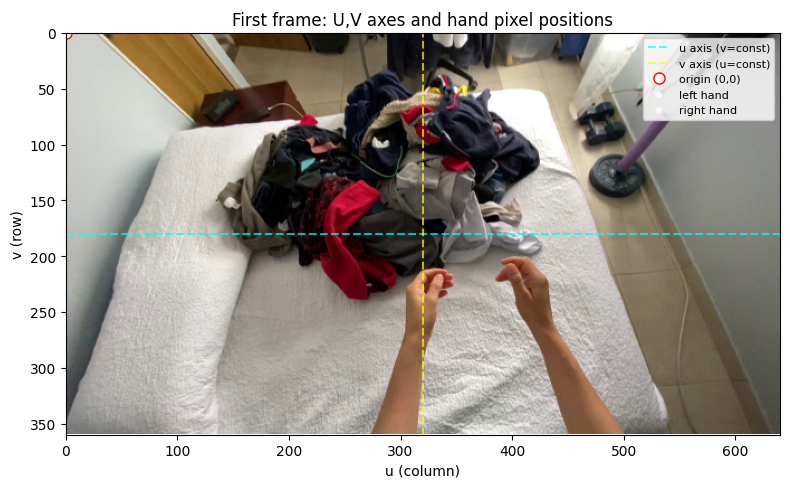

In [ ]:
# Plot first frame with U,V axes and hand pixel positions
batch_0 = make_batch_for_frame(0)
for tr in transform_list:
    batch_0 = tr.transform(batch_0)
actions_0 = batch_0["actions_cartesian"]
left_xyz = actions_0[:, :3]
right_xyz = actions_0[:, 6:9]
left_px = cam_frame_to_cam_pixels(left_xyz, intrinsics)[:, :2]
right_px = cam_frame_to_cam_pixels(right_xyz, intrinsics)[:, :2]

frame_0 = get_frame(0)
H, W = frame_0.shape[:2]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(frame_0)
ax.set_xlabel("u (column)")
ax.set_ylabel("v (row)")
ax.set_title("First frame: U,V axes and hand pixel positions")

# Draw U axis (horizontal) at v = H/2
ax.axhline(y=H/2, color="cyan", linestyle="--", alpha=0.7, label="u axis (v=const)")
# Draw V axis (vertical) at u = W/2
ax.axvline(x=W/2, color="yellow", linestyle="--", alpha=0.7, label="v axis (u=const)")
# Origin marker
ax.plot(0, 0, "wo", markersize=8, markeredgecolor="red", label="origin (0,0)")
ax.annotate("(0,0)", (0, 0), xytext=(10, 10), textcoords="offset points", color="white", fontsize=9)

# Scatter hand pixels (left=blue, right=red), darker = later in chunk
ax.scatter(left_px[:, 0], left_px[:, 1], c=np.linspace(0, 1, len(left_px)), cmap="Blues", s=15, label="left hand")
ax.scatter(right_px[:, 0], right_px[:, 1], c=np.linspace(0, 1, len(right_px)), cmap="Reds", s=15, label="right hand")
ax.legend(loc="upper right", fontsize=8)
ax.set_xlim(0, W)
ax.set_ylim(H, 0)
plt.tight_layout()
plt.show()